
## Introduction & Objectives
The primary goal of this notebook is to perform exploratory data analysis (EDA) on a stroke dataset to identify key cardiovascular risk factors. The main focus is to provide meaningful and clear data driven insights regarding cardiovascular risk factors through rigorous data profiling, feature engineering, and mathematical validation. By combining visual analytics with statistical strictness, this notebook aims to provide a reliable risk profile identifying the key drivers of stroke events.

### 1. Import all the neccessary libraries for the project

In [38]:
import warnings
from IPython.core.pylabtools import figsize
from unicodedata import category

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [39]:
sns.set_theme(style="whitegrid", palette="muted")
sns.color_palette("hls", 8)

def load_the_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    return df

df = load_the_data('healthcare-dataset-stroke-data.xls')

| Target Variables

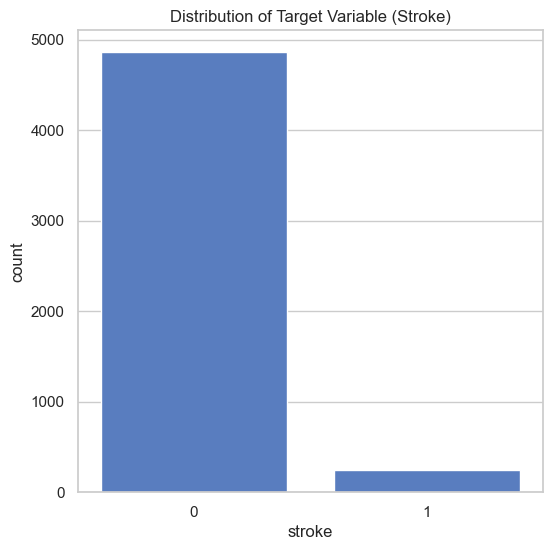

In [40]:
def target_variables(dataframe) -> None:

    plt.figure(figsize=(6, 6))
    sns.countplot(x=dataframe['stroke'])
    plt.title("Distribution of Target Variable (Stroke)")
    plt.show()

target_variables(df)

In [41]:
print(df.shape)
print(df.describe())
print(df.info())

(5110, 12)
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.1

In [42]:
print(df.isna().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


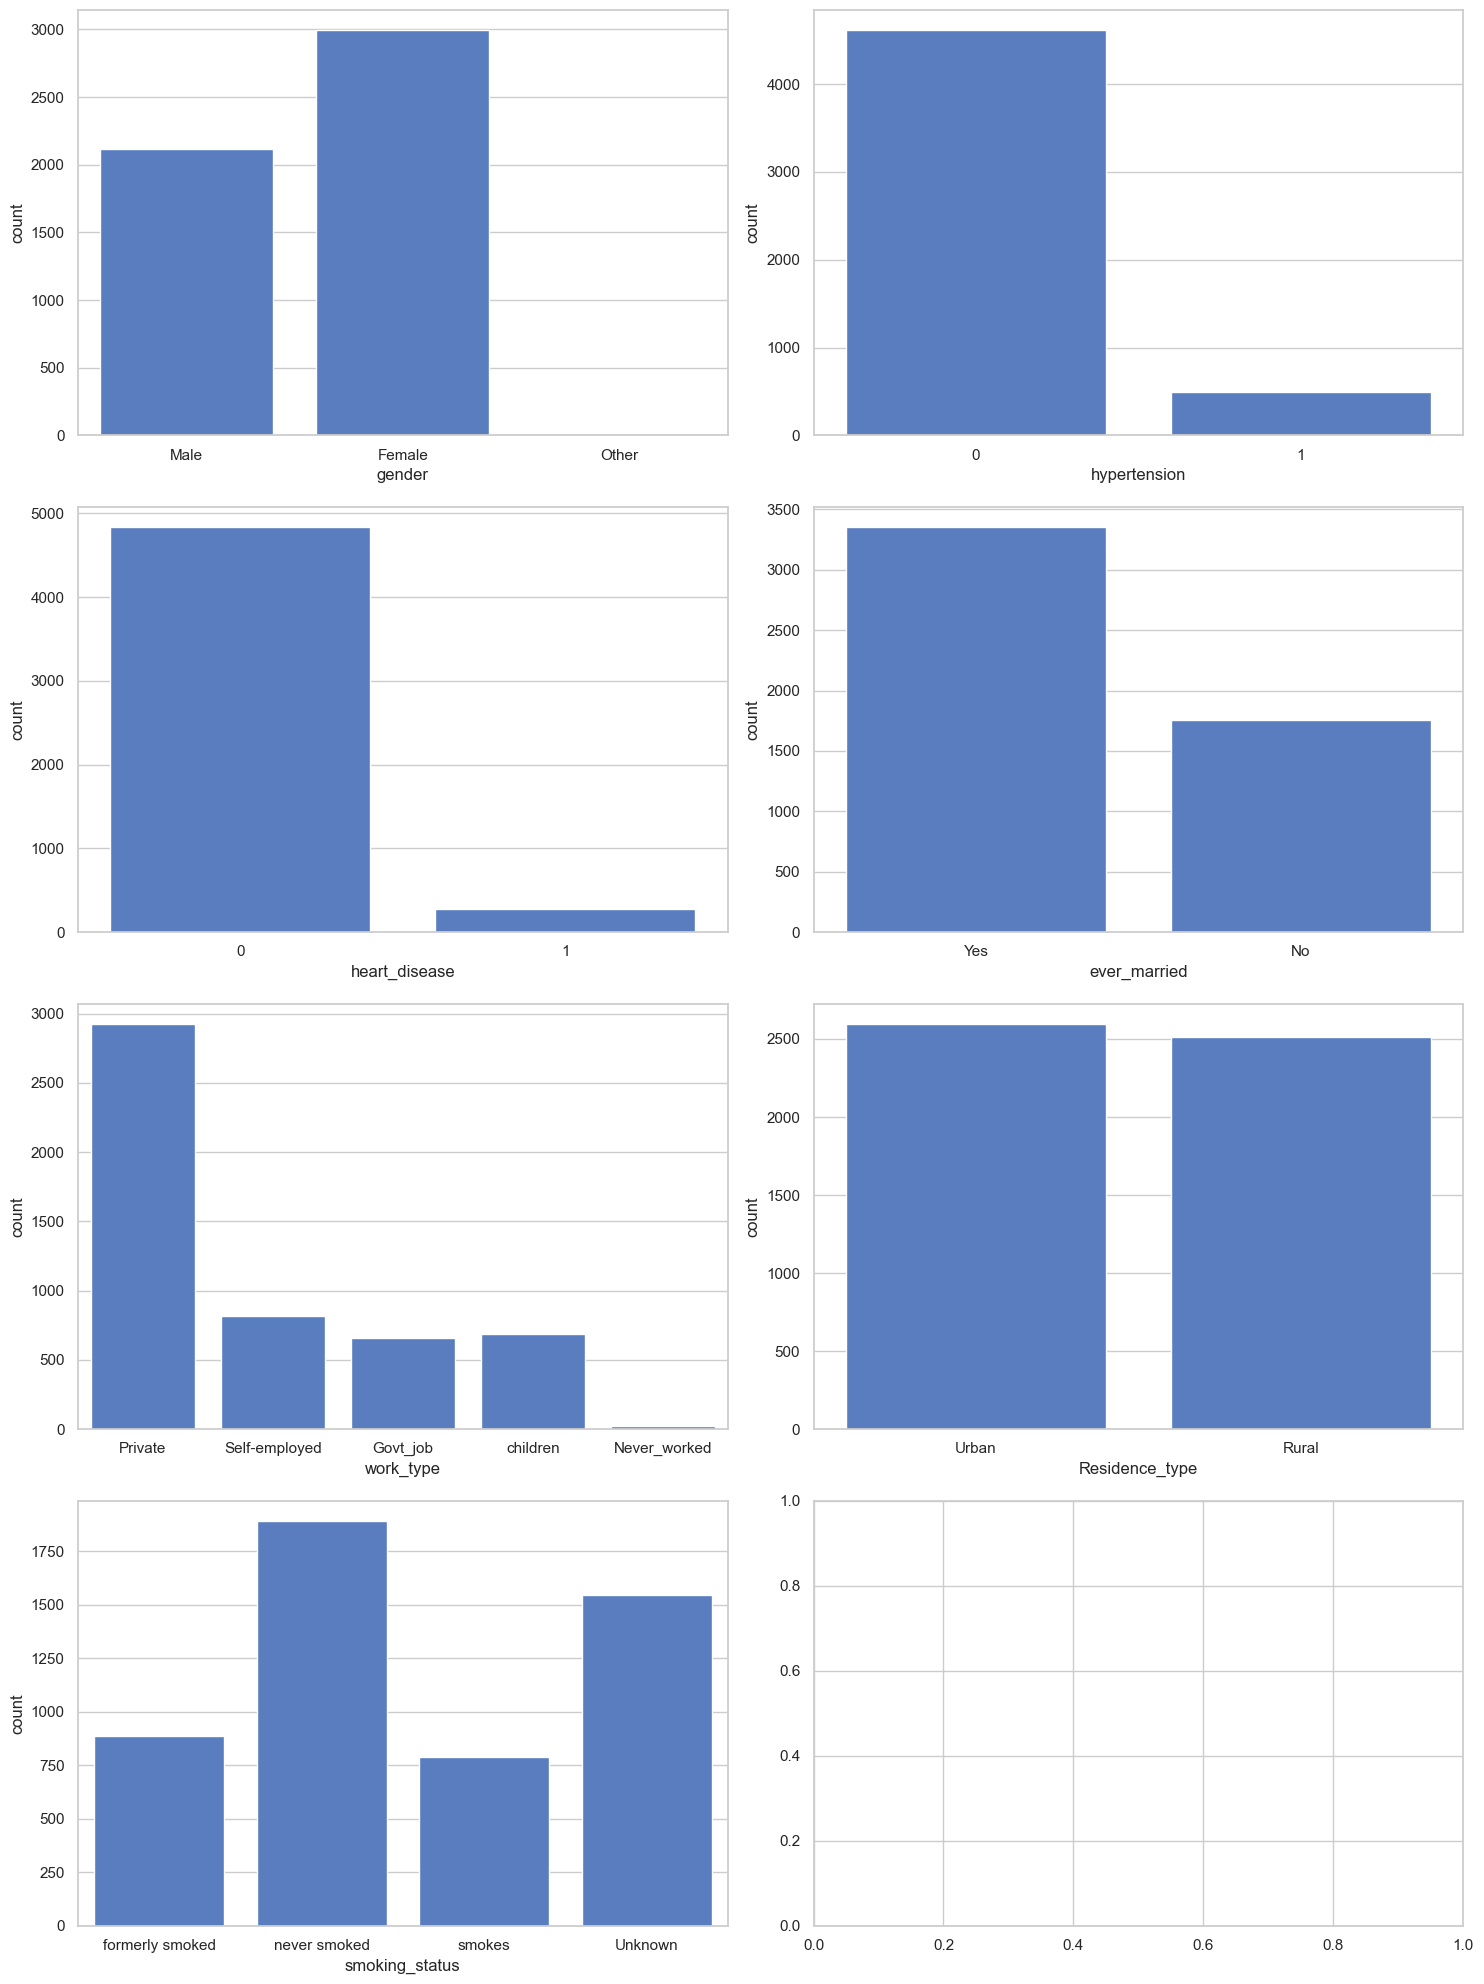

In [43]:
def category_vairables(dataframe) -> None:
    categorical_variables = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15,20))


    for var, subplot in zip(categorical_variables, axes.flatten()):
        sns.countplot(x=var, data=dataframe, ax=subplot)
    '''    for label in subplot.get_xticklabels():
            label.set_rotation(45)'''

    plt.tight_layout()
    plt.show()

category_vairables(df)

***The interpretations of the results:***

The key observations of the categorical variables:
gender: There are more female than male patients, and the number of patients who identity themselves as others are quite minute
hypertension: The major part of the pationts do not have hypertension.
heart_disease: The majority of patients do not have heart disease.
ever_married: A high percentage of patients report ever-married status
work_type: The private working employees comprise the largest share of the patient base. Moreover, the self-employed individuals and children also take a considerable part. Meanwhile, public sector workers and those who have never worked account for the lowest percentages.

III | Continous Vairables

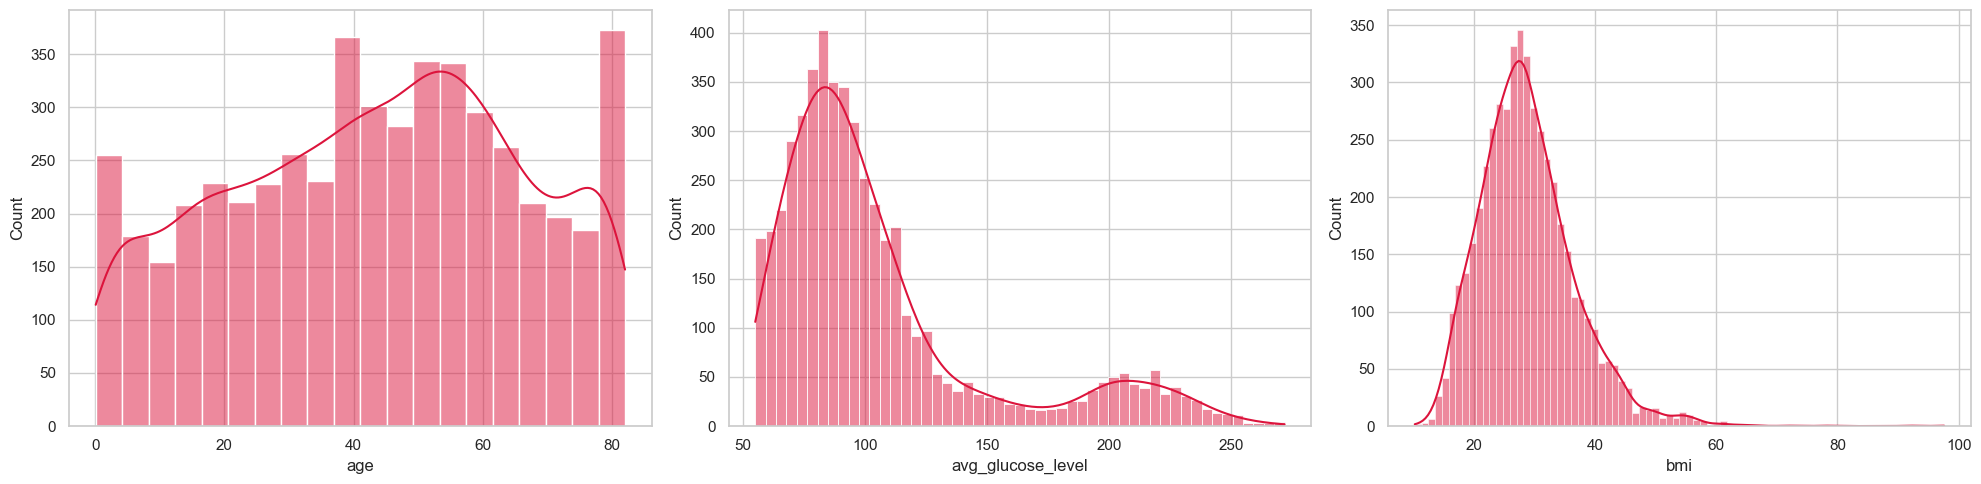

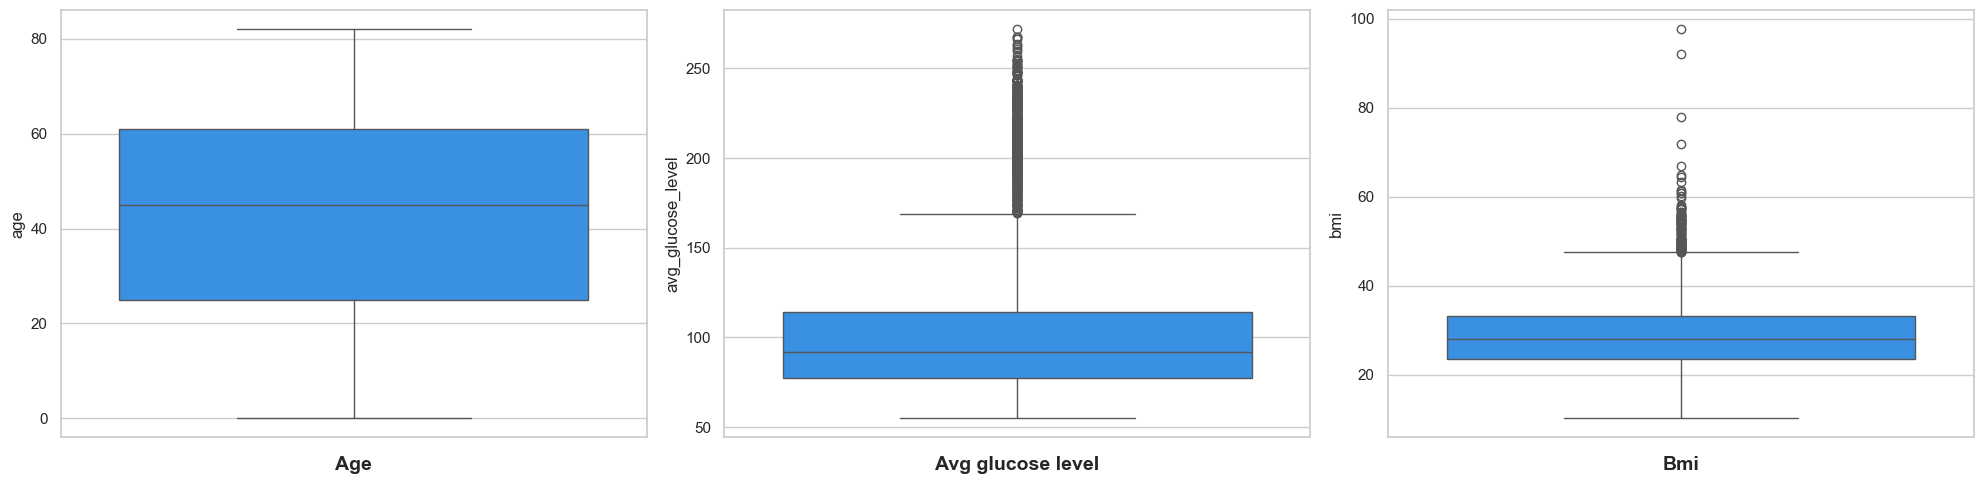

In [46]:
def continuous_variables_histogram(dataframe) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.histplot(dataframe[var], kde=True, ax=subplot, color='crimson')

    plt.tight_layout()
    plt.show()

def continuous_variables_boxplot(dataframe) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1, 3, figsize=(20,5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.boxplot(y=dataframe[var], ax=subplot, color='dodgerblue')
        subplot.set_xlabel(var.replace("_", " "). capitalize(), fontsize=14, fontweight='bold')
        subplot.set_title("")

    plt.tight_layout()
    plt.show()

continuous_variables_histogram(df)
continuous_variables_boxplot(df)